In [78]:
# basic
import numpy as np
import pandas as pd

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder

# pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# imbalance
from imblearn.over_sampling import SMOTE

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier

# evaluation
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset

In [79]:
train_df = pd.read_csv(r"C:\Users\Osama Youssef\Downloads\AI Projects\fraud-detection-system\data\fraudTrain.csv")
test_df = pd.read_csv(r"C:\Users\Osama Youssef\Downloads\AI Projects\fraud-detection-system\data\fraudTest.csv")

In [80]:
print(train_df.shape)
print(test_df.shape)

(1296675, 23)
(555719, 23)


In [81]:
train_df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [82]:
train_df.info(),train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

(None,
          Unnamed: 0        cc_num           amt           zip           lat  \
 count  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06   
 mean   6.483370e+05  4.171920e+17  7.035104e+01  4.880067e+04  3.853762e+01   
 std    3.743180e+05  1.308806e+18  1.603160e+02  2.689322e+04  5.075808e+00   
 min    0.000000e+00  6.041621e+10  1.000000e+00  1.257000e+03  2.002710e+01   
 25%    3.241685e+05  1.800429e+14  9.650000e+00  2.623700e+04  3.462050e+01   
 50%    6.483370e+05  3.521417e+15  4.752000e+01  4.817400e+04  3.935430e+01   
 75%    9.725055e+05  4.642255e+15  8.314000e+01  7.204200e+04  4.194040e+01   
 max    1.296674e+06  4.992346e+18  2.894890e+04  9.978300e+04  6.669330e+01   
 
                long      city_pop     unix_time     merch_lat    merch_long  \
 count  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06   
 mean  -9.022634e+01  8.882444e+04  1.349244e+09  3.853734e+01 -9.022646e+01   
 std    1.375908e+01  3.019564e

In [83]:
train_df = train_df.drop(columns =['Unnamed: 0','cc_num','first','last','street','trans_num','zip'])
test_df = test_df.drop(columns =['Unnamed: 0','cc_num','first','last','street','trans_num','zip'])

In [84]:
## check outliers
def outliers(df,column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column]<lower_bound)|(df[column]>upper_bound)]
    return outliers
num_cols = train_df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    out = outliers(train_df, col)
    percent = len(out) / len(train_df) * 100
    print(col, ":", round(percent,2), "%")

amt : 5.19 %
lat : 0.36 %
long : 3.85 %
city_pop : 18.72 %
unix_time : 0.0 %
merch_lat : 0.38 %
merch_long : 3.24 %
is_fraud : 0.58 %


In [85]:
## isolate time
train_df["trans_date_trans_time"] = pd.to_datetime(train_df["trans_date_trans_time"])
train_df["hour"] = train_df["trans_date_trans_time"].dt.hour
train_df = train_df.drop(columns = 'trans_date_trans_time')

test_df["trans_date_trans_time"] = pd.to_datetime(test_df["trans_date_trans_time"])
test_df["hour"] = test_df["trans_date_trans_time"].dt.hour
test_df = test_df.drop(columns = 'trans_date_trans_time')

In [86]:
##calculate age
train_df["dob"] = pd.to_datetime(train_df["dob"])
train_df["age"] = (pd.Timestamp.now() - train_df["dob"]).dt.days // 365
train_df = train_df.drop(columns = 'dob')

test_df["dob"] = pd.to_datetime(test_df["dob"])
test_df["age"] = (pd.Timestamp.now() - test_df["dob"]).dt.days // 365
test_df = test_df.drop(columns = 'dob')

In [87]:
## calculate distances
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c
train_df["distance"] = haversine(
    train_df["lat"],
    train_df["long"],
    train_df["merch_lat"],
    train_df["merch_long"])
test_df["distance"] = haversine(
    test_df["lat"],
    test_df["long"],
    test_df["merch_lat"],
    test_df["merch_long"])
cols_to_drop = ["lat", "long", "merch_lat", "merch_long"]
train_df.drop(columns=cols_to_drop, inplace=True)
test_df.drop(columns=cols_to_drop, inplace=True)

In [88]:
oo = OneHotEncoder(sparse_output=False)
encoded = oo.fit_transform(train_df[['gender','category','state']])
encoded_df = pd.DataFrame(
    encoded,
    columns=oo.get_feature_names_out(['gender','category','state'])
)
train_df = pd.concat([train_df.drop(['gender','category','state'], axis=1), encoded_df], axis=1)
onehot_cols = train_df.filter(regex='^(gender_|category_|state_)').columns
train_df[onehot_cols] = train_df[onehot_cols].astype('bool')

In [89]:
encoded_test = oo.transform(test_df[['gender','category','state']])
encoded_test_df = pd.DataFrame(
    encoded_test,
    columns=oo.get_feature_names_out(['gender','category','state'])
)
test_df = pd.concat(
    [test_df.drop(['gender','category','state'], axis=1), encoded_test_df],
    axis=1
)
test_df[onehot_cols] = test_df[onehot_cols].astype('bool')

In [90]:
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
train_df[['merchant','city','job']] = enc.fit_transform(train_df[['merchant','city','job']])
test_df[['merchant','city','job']] = enc.transform(test_df[['merchant','city','job']])

In [91]:
X = train_df.drop("is_fraud", axis=1)
y = train_df["is_fraud"]

In [92]:
ss = StandardScaler()
X = ss.fit_transform(X)

In [93]:
X_test = test_df.drop("is_fraud", axis=1)
y_test = test_df["is_fraud"]

X_test = ss.transform(X_test)

In [94]:
X,y,X_test,y_test

(array([[ 0.85165441, -0.40782607,  0.31220693, ..., -0.15222861,
         -0.14217409, -0.12299022],
        [-0.50688018,  0.23003923,  0.64476684, ..., -0.15222861,
         -0.14217409, -0.12299022],
        [ 0.23459108,  0.93414872,  0.08792233, ..., -0.15222861,
         -0.14217409, -0.12299022],
        ...,
        [ 1.27464137,  0.22193025, -0.38384871, ..., -0.15222861,
         -0.14217409, -0.12299022],
        [ 0.82677283,  0.02837499,  0.09952326, ..., -0.15222861,
         -0.14217409, -0.12299022],
        [ 0.13506474, -0.41200532,  1.30215272, ..., -0.15222861,
         -0.14217409, -0.12299022]], shape=(1296675, 76)),
 0          0
 1          0
 2          0
 3          0
 4          0
           ..
 1296670    0
 1296671    0
 1296672    0
 1296673    0
 1296674    0
 Name: is_fraud, Length: 1296675, dtype: int64,
 array([[-0.11872744, -0.42098758, -1.0721704 , ..., -0.15222861,
         -0.14217409, -0.12299022],
        [ 1.23483084, -0.25269494, -1.65995071, 

In [95]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [96]:
IF = IsolationForest(n_estimators = 200,
max_samples = 10000,
contamination = 0.006,
n_jobs = -1,
random_state = 42)
IF.fit(X_train)
y_train_pred = IF.predict(X_train)

In [97]:
pd.value_counts(y_train_pred)

C:\Users\Osama Youssef\AppData\Local\Temp\ipykernel_26248\1249470768.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(y_train_pred)


 1    1031115
-1       6225
Name: count, dtype: int64

In [98]:
train_scores = IF.decision_function(X_train)
val_scores   = IF.decision_function(X_val)
test_scores  = IF.decision_function(X_test)

In [99]:
X_train = np.hstack([X_train, train_scores.reshape(-1,1)])
X_val   = np.hstack([X_val, val_scores.reshape(-1,1)])
X_test  = np.hstack([X_test, test_scores.reshape(-1,1)])

In [100]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [101]:
class FraudNN(nn.Module):

    def __init__(self, input_dim, hidden_dims, dropout):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h

        layers.append(nn.Linear(prev_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

class Trainer:

    def __init__(self, model, optimizer, loss_fn, device):
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.device = device

    def train_epoch(self, dataloader):
        self.model.train()
        total_loss = 0
        for x, y in dataloader:
            x = x.to(self.device)
            y = y.to(self.device)
            preds = self.model(x)
            loss = self.loss_fn(preds, y)
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(dataloader)
        return avg_loss

    def validate(self, dataloader):
        self.model.eval()
        with torch.no_grad():
            for x, y in dataloader:
                x = x.to(self.device)
                y = y.to(self.device)
                preds = self.model(x)

class FraudDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [102]:
config = {
    "data": {
        "batch_size": 512
    },

    "model": {
        "input_dim": 77,
        "hidden_dims": [128, 64],
        "dropout": 0.2
    },

    "optimizer": {
        "type": "adam",
        "lr": 0.001
    },

    "training": {
        "epochs": 20
    }
}

In [103]:
train_dataset = FraudDataset(X_train_smote, y_train_smote)
val_dataset   = FraudDataset(X_val, y_val)
test_dataset  = FraudDataset(X_test, y_test)

In [104]:
train_loader = DataLoader(train_dataset, batch_size=config["data"]["batch_size"], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config["data"]["batch_size"])
test_loader = DataLoader(test_dataset, batch_size=config["data"]["batch_size"])

In [105]:
model = FraudNN(**config["model"]).to(device)

In [106]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=config["optimizer"]["lr"]
)

In [107]:
loss_fn = nn.BCEWithLogitsLoss()

In [108]:
trainer = Trainer(
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device="cuda"
)

In [109]:
for epoch in range(config["training"]["epochs"]):
    trainer.train_epoch(train_loader)
    trainer.validate(val_loader)

trainer.validate(test_loader)

In [110]:
train_losses = []
val_losses = []

val_precision = []
val_recall = []
val_f1 = []
val_auc = []

In [111]:
def evaluate_model(model, dataloader):

    model.eval()

    all_preds = []
    all_probs = []
    all_targets = []

    total_loss = 0

    with torch.no_grad():

        for x, y in dataloader:

            x = x.to(device)
            y = y.to(device)

            preds = model(x)

            loss = loss_fn(preds, y)

            total_loss += loss.item()

            probs = torch.sigmoid(preds)

            predicted = (probs > 0.5).float()

            all_probs.extend(probs.cpu().numpy().flatten())
            all_preds.extend(predicted.cpu().numpy().flatten())
            all_targets.extend(y.cpu().numpy().flatten())

    avg_loss = total_loss / len(dataloader)

    precision = precision_score(all_targets, all_preds)
    recall = recall_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds)
    auc = roc_auc_score(all_targets, all_probs)

    return avg_loss, precision, recall, f1, auc, all_preds, all_targets

In [112]:
for epoch in range(config["training"]["epochs"]):

    train_loss = trainer.train_epoch(train_loader)

    val_loss, precision, recall, f1, auc, preds, targets = evaluate_model(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    val_precision.append(precision)
    val_recall.append(recall)
    val_f1.append(f1)
    val_auc.append(auc)

    print(f"\nEpoch {epoch+1}")

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"AUC: {auc:.4f}")


Epoch 1
Train Loss: 0.0143
Val Loss: 0.0196
Precision: 0.5447
Recall: 0.8854
F1: 0.6744
AUC: 0.9906

Epoch 2
Train Loss: 0.0142
Val Loss: 0.0212
Precision: 0.5232
Recall: 0.8947
F1: 0.6603
AUC: 0.9911

Epoch 3
Train Loss: 0.0138
Val Loss: 0.0207
Precision: 0.5428
Recall: 0.8827
F1: 0.6722
AUC: 0.9909

Epoch 4
Train Loss: 0.0137
Val Loss: 0.0207
Precision: 0.5378
Recall: 0.8914
F1: 0.6708
AUC: 0.9909

Epoch 5
Train Loss: 0.0138
Val Loss: 0.0200
Precision: 0.5393
Recall: 0.8961
F1: 0.6733
AUC: 0.9912

Epoch 6
Train Loss: 0.0134
Val Loss: 0.0210
Precision: 0.5381
Recall: 0.8894
F1: 0.6705
AUC: 0.9903

Epoch 7
Train Loss: 0.0135
Val Loss: 0.0201
Precision: 0.5441
Recall: 0.8834
F1: 0.6734
AUC: 0.9914

Epoch 8
Train Loss: 0.0130
Val Loss: 0.0203
Precision: 0.5506
Recall: 0.8841
F1: 0.6786
AUC: 0.9911

Epoch 9
Train Loss: 0.0130
Val Loss: 0.0194
Precision: 0.5767
Recall: 0.8767
F1: 0.6957
AUC: 0.9907

Epoch 10
Train Loss: 0.0127
Val Loss: 0.0200
Precision: 0.5741
Recall: 0.8854
F1: 0.6965
A

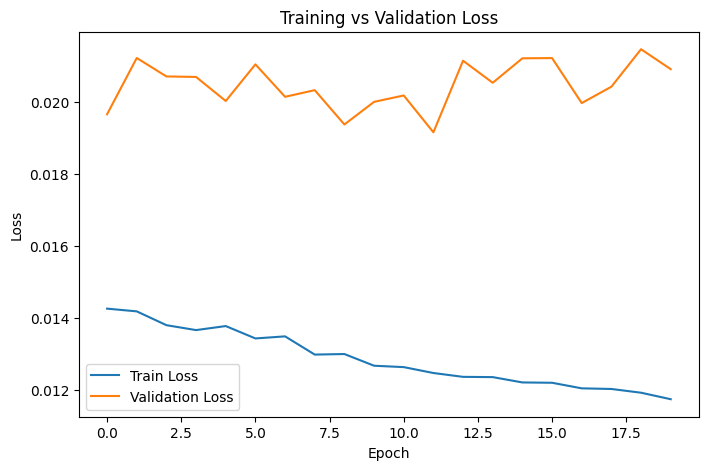

In [113]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.title("Training vs Validation Loss")

plt.show()

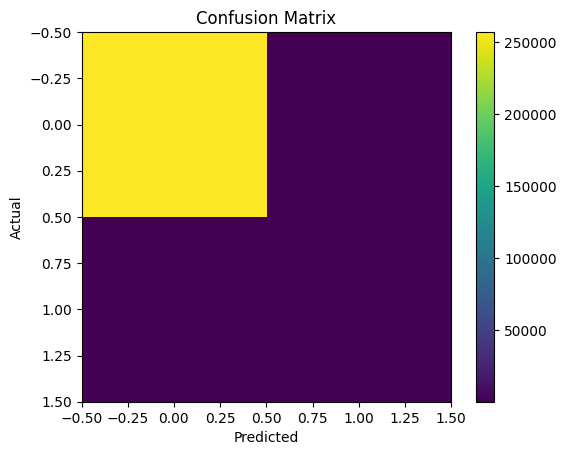

In [114]:
cm = confusion_matrix(targets, preds)

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [115]:
fraud_indices = np.where(np.array(targets) == 1)[0]

for i in fraud_indices[:10]:
    print("Prediction:", preds[i], "Actual:", targets[i])

Prediction: 0.0 Actual: 1.0
Prediction: 1.0 Actual: 1.0
Prediction: 1.0 Actual: 1.0
Prediction: 1.0 Actual: 1.0
Prediction: 1.0 Actual: 1.0
Prediction: 1.0 Actual: 1.0
Prediction: 1.0 Actual: 1.0
Prediction: 1.0 Actual: 1.0
Prediction: 1.0 Actual: 1.0
Prediction: 1.0 Actual: 1.0


In [116]:
print(torch.cuda.is_available())

True


In [117]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')